# Classificação de Risco de Crédito — KNN & Árvore de Decisão

Este notebook aplica aprendizado de máquina supervisionado para classificar clientes em categorias de **risco de crédito** (baixo, médio, alto).

**Dataset:** planilha criada manualmente com 28 clientes fictícios, contendo as colunas:
- `idade` — idade do cliente (anos)
- `renda_mensal` — renda mensal (R$)
- `score_credito` — pontuação de crédito (0–1000)
- `tempo_emprego_anos` — tempo no emprego atual (anos)
- `dividas_ativas` — número de dívidas em aberto
- `risco` — **alvo**: `baixo`, `medio` ou `alto`

**Modelos treinados:** K-Nearest Neighbors (KNN) e Árvore de Decisão.

**Metodologia:**
1. Carregamento dos dados via Google Sheets (formato TSV)
2. Seleção de diferentes conjuntos de features (A a E)
3. Divisão treino/teste fixo (23 treino / 5 teste)
4. Treinamento, avaliação e comparação dos modelos


In [1]:
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

SHEET_ID = "1n2q0o1uedtu89xlEQZe0N5mZJaBMIEzCxw51F92cvl0"
GID = "0"  # aba Página1
url_tsv = f"https://docs.google.com/spreadsheets/d/{SHEET_ID}/export?format=tsv&gid={GID}"

# TSV + vírgula decimal
df = pd.read_csv(url_tsv, sep="\t", decimal=",")

print("Colunas lidas:", list(df.columns))
display(df.head())

Colunas lidas: ['idade', 'renda_mensal', 'score_credito', 'tempo_emprego_anos', 'dividas_ativas', 'risco']


,idade,renda_mensal,score_credito,tempo_emprego_anos,dividas_ativas,risco
0,22,1800,450,1,3,alto
1,25,2200,480,2,2,alto
2,28,3000,520,3,1,medio
3,35,4500,650,8,0,baixo
4,42,5200,700,10,0,baixo


In [4]:
FEATURES = ["idade", "renda_mensal", "score_credito", "tempo_emprego_anos", "dividas_ativas"]

TARGET = "risco"            # coluna-alvo: baixo, medio, alto

for col in FEATURES:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Normaliza o target e remove linhas inválidas
df[TARGET] = df[TARGET].astype(str).str.strip().str.lower()
df = df.dropna(subset=FEATURES + [TARGET]).copy()  # remove linhas com valores inválidos

print("\nDistribuição do target:")
print(df[TARGET].value_counts())



Distribuição do target:
risco
baixo    41
medio    37
alto     23
Name: count, dtype: int64


In [5]:
le = LabelEncoder()
y_all = le.fit_transform(df[TARGET])
X_all = df[FEATURES].values

print("\nClasses:", list(le.classes_))
print("Total linhas válidas:", len(df))


Classes: ['alto', 'baixo', 'medio']
Total linhas válidas: 101


In [6]:

RANDOM_STATE = 42
df_shuffled = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
limite_teste=int(len(df)*0.20) # Split : 20% teste + 80% treino
test_df  = df_shuffled.iloc[:limite_teste].copy()
train_df = df_shuffled.iloc[limite_teste:len(df)].copy()
X_train = train_df[FEATURES].values
y_train = le.transform(train_df[TARGET])
X_test  = test_df[FEATURES].values
y_test  = le.transform(test_df[TARGET])
print("\nTreino:", len(train_df), "| Teste:", len(test_df))



Treino: 81 | Teste: 20


In [7]:
def dist_classes(frame, target_col, titulo):
    vc = frame[target_col].value_counts(dropna=False)
    pct = (vc / len(frame) * 100).round(1)
    out = pd.DataFrame({"qtd": vc, "%": pct})
    print(f"\n=== {titulo} (n={len(frame)}) ===")
    display(out)

dist_classes(df, TARGET, "Dataset completo")
dist_classes(train_df, TARGET, "Treino")
dist_classes(test_df, TARGET, "Teste")


=== Dataset completo (n=101) ===


,qtd,%
risco,,
baixo,41,40.6
medio,37,36.6
alto,23,22.8



=== Treino (n=81) ===


,qtd,%
risco,,
baixo,32,39.5
medio,29,35.8
alto,20,24.7



=== Teste (n=20) ===


,qtd,%
risco,,
baixo,9,45.0
medio,8,40.0
alto,3,15.0


In [8]:
# Modelo KNN
K = 5
WEIGHTS = "distance"  # "uniform" ou "distance"

model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=K, weights=WEIGHTS))
])

model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('knn', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30

In [9]:
# Avaliação

y_pred = model.predict(X_test)

print("\nFeatures usadas:", FEATURES)
print("Acurácia:", accuracy_score(y_test, y_pred))
print("\nRelatório:")
print(classification_report(y_test, y_pred, target_names=le.classes_))
print("Matriz de confusão (real x previsto):")
print(confusion_matrix(y_test, y_pred))



Features usadas: ['idade', 'renda_mensal', 'score_credito', 'tempo_emprego_anos', 'dividas_ativas']
Acurácia: 1.0

Relatório:
              precision    recall  f1-score   support

        alto       1.00      1.00      1.00         3
       baixo       1.00      1.00      1.00         9
       medio       1.00      1.00      1.00         8

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20

Matriz de confusão (real x previsto):
[[3 0 0]
 [0 9 0]
 [0 0 8]]


In [10]:
# Resultado detalhado do teste — KNN
test_df["classe_prevista"] = le.inverse_transform(y_pred)
display(test_df[FEATURES + [TARGET, "classe_prevista"]])


,idade,renda_mensal,score_credito,tempo_emprego_anos,dividas_ativas,risco,classe_prevista
0,29,2950,535,4,2,medio,medio
1,33,3500,590,5,1,medio,medio
2,37,4500,665,8,1,baixo,baixo
3,40,5000,690,9,0,baixo,baixo
4,32,3400,580,5,1,medio,medio
5,49,6100,730,14,0,baixo,baixo
6,48,5900,715,13,0,baixo,baixo
7,30,3000,550,4,2,medio,medio
8,33,3500,590,5,1,medio,medio
9,22,1800,450,1,3,alto,alto



=== Árvore de decisão ===
Features usadas: ['idade', 'renda_mensal', 'score_credito', 'tempo_emprego_anos', 'dividas_ativas']
Acurácia: 1.0

Relatório:
              precision    recall  f1-score   support

        alto       1.00      1.00      1.00         3
       baixo       1.00      1.00      1.00         9
       medio       1.00      1.00      1.00         8

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20

Matriz de confusão (real x previsto):
[[3 0 0]
 [0 9 0]
 [0 0 8]]


,idade,renda_mensal,score_credito,tempo_emprego_anos,dividas_ativas,risco,classe_prevista_arvore
0,29,2950,535,4,2,medio,medio
1,33,3500,590,5,1,medio,medio
2,37,4500,665,8,1,baixo,baixo
3,40,5000,690,9,0,baixo,baixo
4,32,3400,580,5,1,medio,medio
5,49,6100,730,14,0,baixo,baixo
6,48,5900,715,13,0,baixo,baixo
7,30,3000,550,4,2,medio,medio
8,33,3500,590,5,1,medio,medio
9,22,1800,450,1,3,alto,alto


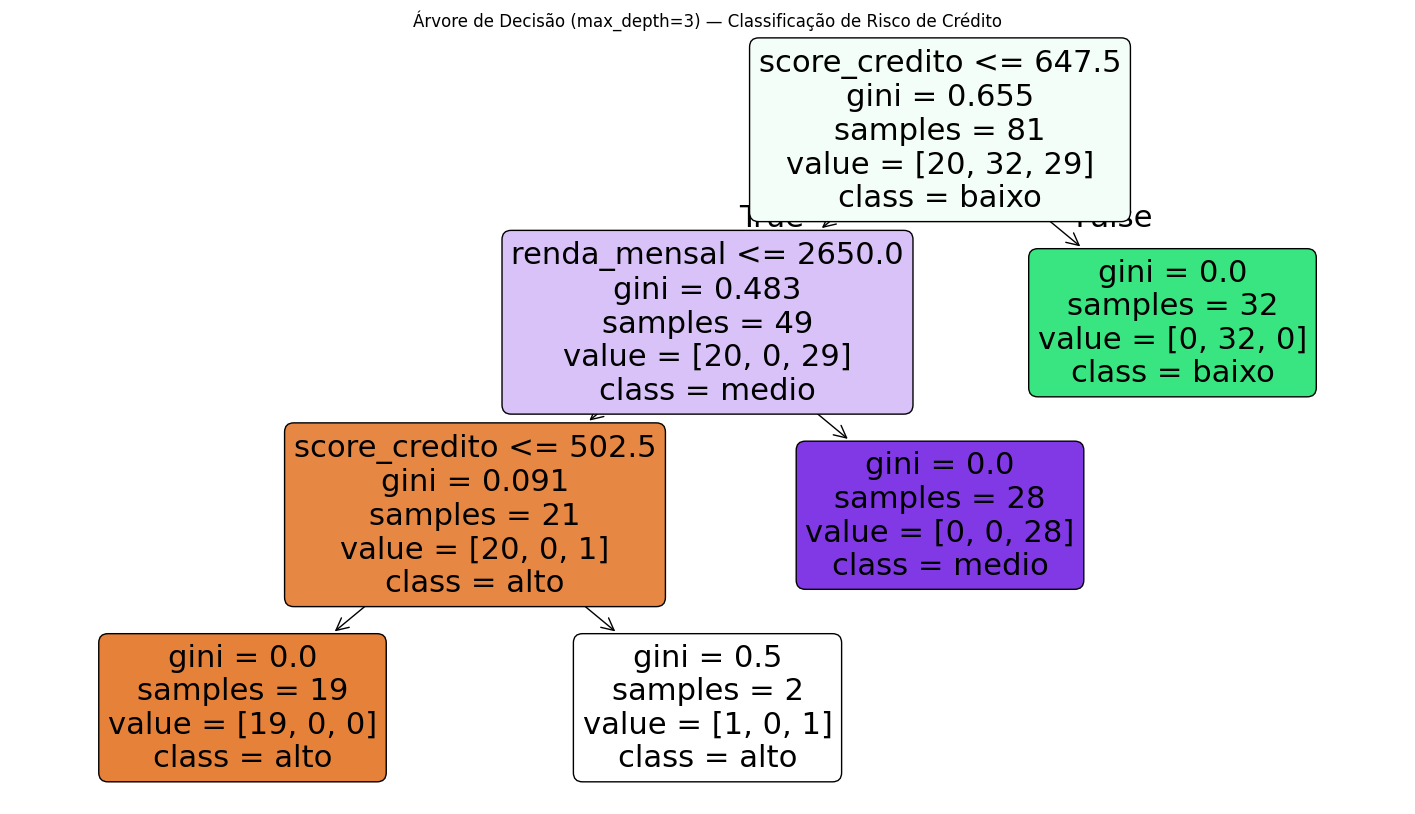

In [11]:
# ========= Árvore de decisão =========
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

tree = DecisionTreeClassifier(
    max_depth=3,          # controla complexidade/legibilidade
    random_state=RANDOM_STATE
)

tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)

print("\n=== Árvore de decisão ===")
print("Features usadas:", FEATURES)
print("Acurácia:", accuracy_score(y_test, y_pred_tree))
print("\nRelatório:")
print(classification_report(y_test, y_pred_tree, target_names=le.classes_))
print("Matriz de confusão (real x previsto):")
print(confusion_matrix(y_test, y_pred_tree))

# Resultado detalhado do teste
test_df["classe_prevista_arvore"] = le.inverse_transform(y_pred_tree)
display(test_df[FEATURES + [TARGET, "classe_prevista_arvore"]])

# Desenhar a árvore
plt.figure(figsize=(18, 10))
plot_tree(
    tree,
    feature_names=FEATURES,
    class_names=list(le.classes_),
    filled=True,
    rounded=True,
    impurity=True
)
plt.title("Árvore de Decisão (max_depth=3) — Classificação de Risco de Crédito")
plt.show()
